In [2]:
import pystac_client
import rasterio as rio
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import shape
import geopandas as gpd
import rich.table
import planetary_computer

In [20]:
area_of_interest = {
    "type": "Polygon",
    "coordinates": [
        [
            [
              16.463041654789635,
              48.92759430091337
            ],
            [
              16.463041654789635,
              48.8417545124706
            ],
            [
              16.73890818146006,
              48.8417545124706
            ],
            [
              16.73890818146006,
              48.92759430091337
            ],
            [
              16.463041654789635,
              48.92759430091337
            ]
        ]
    ]
}

In [21]:
# catalog = pystac_client.Client.open('https://earth-search.aws.element84.com/v1/')
# catalog = pystac_client.Client.open('https://hda.data.destination-earth.eu/stac/')
catalog = pystac_client.Client.open('https://geoservice.dlr.de/eoc/ogc/stac/v1/')
# catalog = pystac_client.Client.open('https://stac.dataspace.copernicus.eu/v1')
# catalog = pystac_client.Client.open(
#     "https://planetarycomputer.microsoft.com/api/stac/v1",
#     modifier=planetary_computer.sign_inplace,
# )
catalog

<Client id=GeoserverSTACLandingPage>

In [22]:
for collection in catalog.get_collections():
    print(collection.id)

S5P_TROPOMI_L3_P1D_CF
S5P_TROPOMI_L3_P1D_COT
S5P_TROPOMI_L3_P1D_CTH
S5P_TROPOMI_L3_P1D_HCHO
S5P_TROPOMI_L3_P1D_O3
S5P_TROPOMI_L3_P1D_SO2
S5P_TROPOMI_L4_P1D_NO2surf
ENMAP_HSI_L0_QL
ENMAP_HSI_L2A
DatKI_LBMDE_2021
D4H
S2_L2A_MAJA
S2_L2A_MAJA_v2
S2_L3A_WASP
DESIS_HSI_L2A
WSF_2015
WSF_2019
S5P_TROPOMI_L3_P1D_AI_v2
S5P_TROPOMI_L3_P1D_ALH_v2
S5P_TROPOMI_L3_P1D_AOD_v2
S5P_TROPOMI_L3_P1D_ASSA_v2
S5P_TROPOMI_L3_P1D_CF_v2
S5P_TROPOMI_L3_P1D_COT_v2
S5P_TROPOMI_L3_P1D_CTH_v2
S5P_TROPOMI_L3_P1D_HCHO_v2
S5P_TROPOMI_L3_P1D_O3_v2
S5P_TROPOMI_L3_P1D_SO2LH_v2
S5P_TROPOMI_L3_P1D_SO2_v2
S5P_TROPOMI_L3_P1D_UVI_v2
S2-soilsuite-africa-2018-2021-P4Y
S2-soilsuite-europe-2018-2022-P5Y
GL_MOW_DE_P1Y_FC
GL_MOW_DE_P1Y_FREQ
URBAN_DEGREE_DE
FCCL_DE_P1M
CROPTYPES_DE_P1Y
FOREST_STRUCTURE_DE_AGBD_P1Y
FOREST_STRUCTURE_DE_COVER_P1Y
FOREST_STRUCTURE_DE_RH95_P1Y
N2N_NOISE_AI_DE_2017
N2N_NOISE_DE_2017
SAR4TEC_ASCE
SAR4TEC_DESC
SWIM_WE
WSF3D_MATSTOCK
TDM_FNF_50
TDM_DEM_90
SUPERSITES
METOP_GOME2_L3_P1D_BRO
METOP_GOME2_L3_P1D_C

In [24]:
search = catalog.search(
    intersects=area_of_interest,
    datetime=['2020-03-13T00:00:00Z', '2026-03-22T00:00:00Z'],
    collections=[
        #'sentinel-2-l2a',
        'ENMAP_HSI_L2A',
        #'EO.ESA.DAT.SENTINEL-3.OL_2_LFR___',
        #'EO.EUM.DAT.SENTINEL-3.OL_2_WRR___',
        #'landsat-c2-l2'
        ],
)

items = search.item_collection()
for item in items:
    print(item.id)

ENMAP01-____L2A-DT0000152162_20250911T103212Z_016_V010502_20250917T030051Z
ENMAP01-____L2A-DT0000152162_20250911T103208Z_015_V010502_20250917T030051Z
ENMAP01-____L2A-DT0000147513_20250815T103158Z_016_V010502_20250821T190844Z
ENMAP01-____L2A-DT0000147513_20250815T103154Z_015_V010502_20250821T190728Z
ENMAP01-____L2A-DT0000098426_20241022T103205Z_016_V010501_20241102T021729Z
ENMAP01-____L2A-DT0000098426_20241022T103201Z_015_V010501_20241102T021730Z
ENMAP01-____L2A-DT0000094378_20240925T103138Z_016_V010402_20241005T214910Z
ENMAP01-____L2A-DT0000094378_20240925T103134Z_015_V010402_20241005T214553Z
ENMAP01-____L2A-DT0000089986_20240829T103215Z_016_V010402_20240902T154145Z
ENMAP01-____L2A-DT0000089986_20240829T103211Z_015_V010402_20240902T154033Z
ENMAP01-____L2A-DT0000086112_20240802T103146Z_016_V010402_20240811T114246Z
ENMAP01-____L2A-DT0000086112_20240802T103142Z_015_V010402_20240811T113703Z
ENMAP01-____L2A-DT0000079993_20240628T102510Z_001_V010402_20240702T034814Z
ENMAP01-____L2A-DT0000079

In [25]:
items[0]

<Item id=ENMAP01-____L2A-DT0000152162_20250911T103212Z_016_V010502_20250917T030051Z>

https://download.geoservice.dlr.de/ENMAP/files/L2A/2025/09/11/DT0000152162/16/ENMAP01-____L2A-DT0000152162_20250911T103212Z_016_V010502_20250917T030051Z-SPECTRAL_IMAGE_COG.TIF


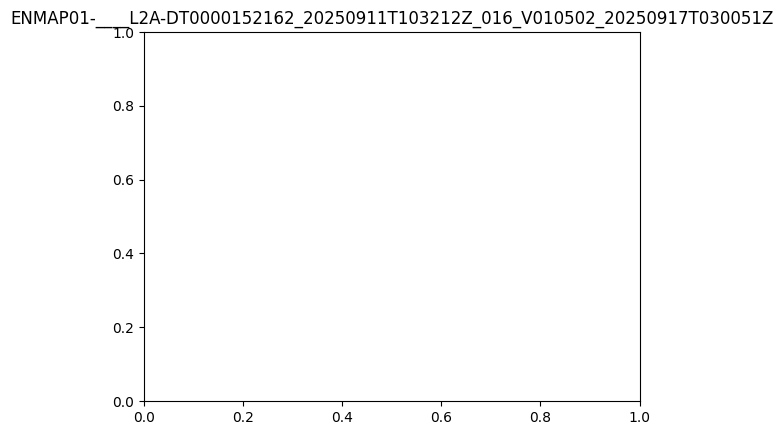

https://download.geoservice.dlr.de/ENMAP/files/L2A/2025/09/11/DT0000152162/15/ENMAP01-____L2A-DT0000152162_20250911T103208Z_015_V010502_20250917T030051Z-SPECTRAL_IMAGE_COG.TIF


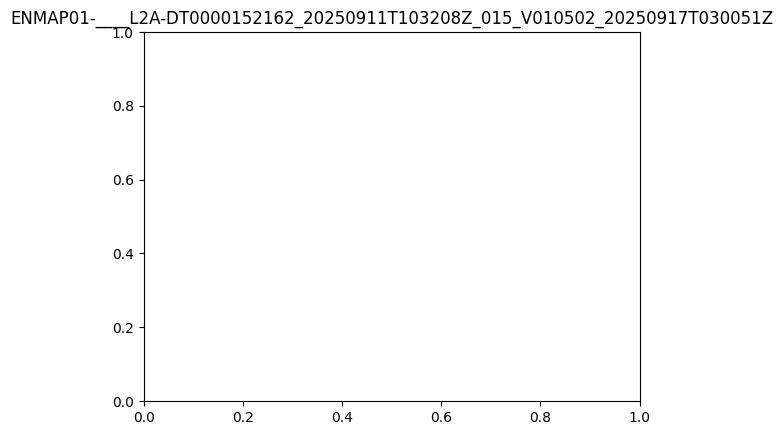

https://download.geoservice.dlr.de/ENMAP/files/L2A/2025/08/15/DT0000147513/16/ENMAP01-____L2A-DT0000147513_20250815T103158Z_016_V010502_20250821T190844Z-SPECTRAL_IMAGE_COG.TIF


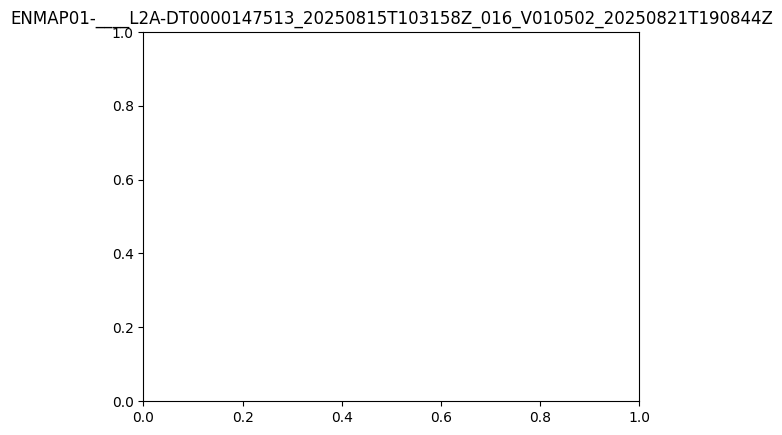

https://download.geoservice.dlr.de/ENMAP/files/L2A/2025/08/15/DT0000147513/15/ENMAP01-____L2A-DT0000147513_20250815T103154Z_015_V010502_20250821T190728Z-SPECTRAL_IMAGE_COG.TIF


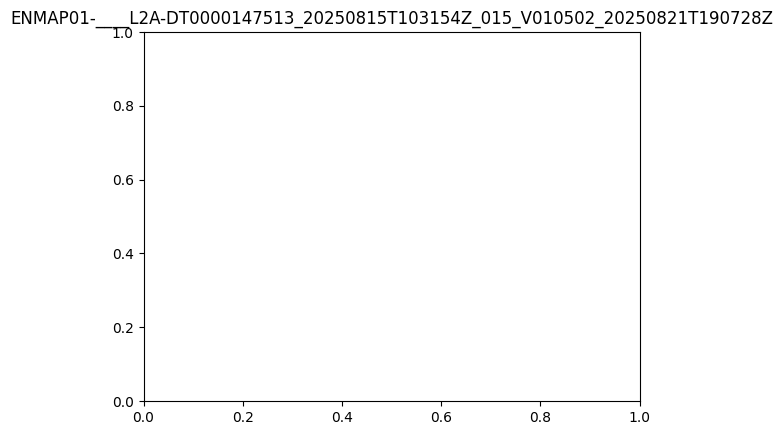

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/10/22/DT0000098426/16/ENMAP01-____L2A-DT0000098426_20241022T103205Z_016_V010501_20241102T021729Z-SPECTRAL_IMAGE_COG.TIF


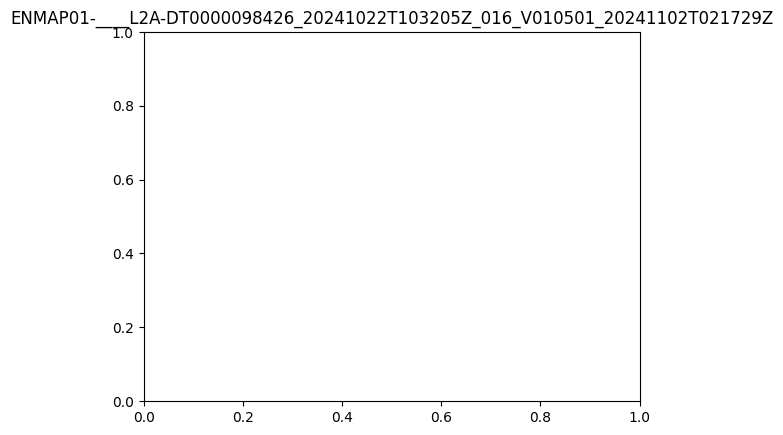

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/10/22/DT0000098426/15/ENMAP01-____L2A-DT0000098426_20241022T103201Z_015_V010501_20241102T021730Z-SPECTRAL_IMAGE_COG.TIF


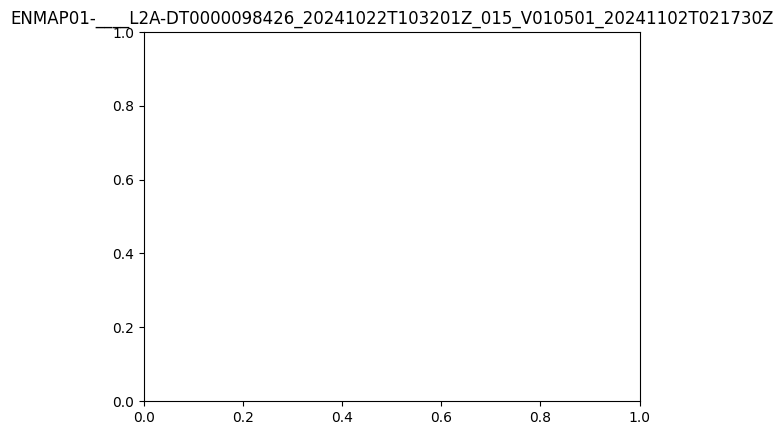

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/09/25/DT0000094378/16/ENMAP01-____L2A-DT0000094378_20240925T103138Z_016_V010402_20241005T214910Z-SPECTRAL_IMAGE_COG.TIF


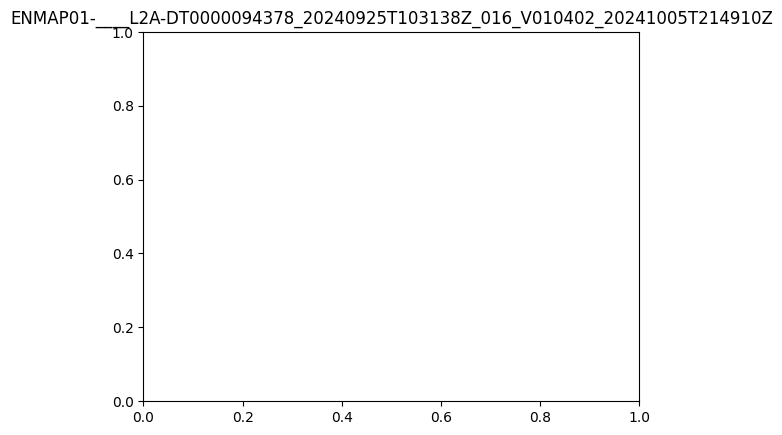

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/09/25/DT0000094378/15/ENMAP01-____L2A-DT0000094378_20240925T103134Z_015_V010402_20241005T214553Z-SPECTRAL_IMAGE_COG.TIF


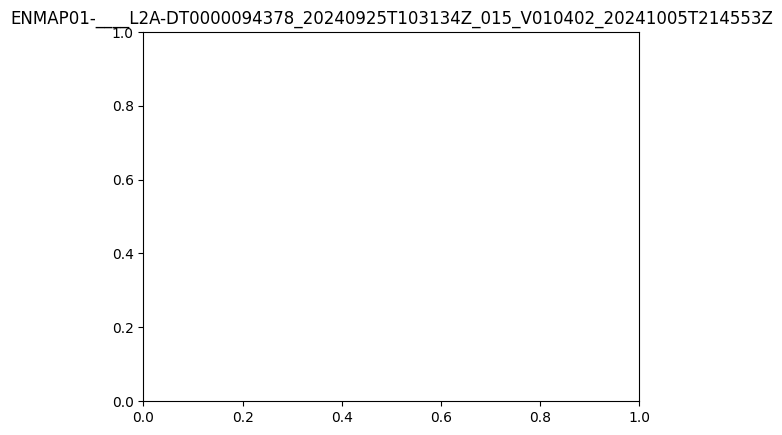

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/08/29/DT0000089986/16/ENMAP01-____L2A-DT0000089986_20240829T103215Z_016_V010402_20240902T154145Z-SPECTRAL_IMAGE_COG.TIF


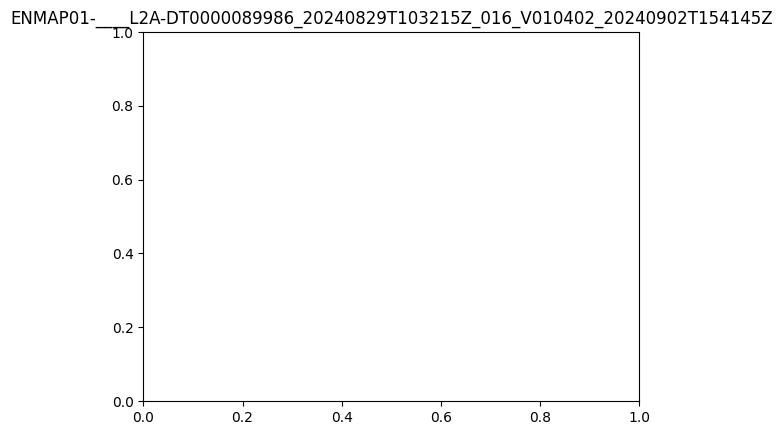

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/08/29/DT0000089986/15/ENMAP01-____L2A-DT0000089986_20240829T103211Z_015_V010402_20240902T154033Z-SPECTRAL_IMAGE_COG.TIF


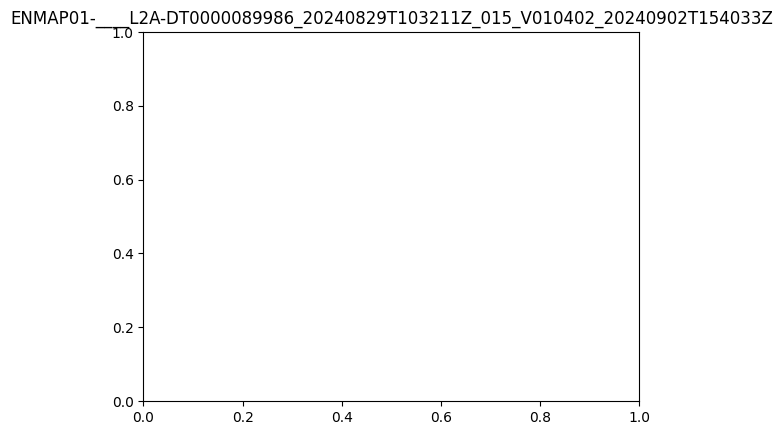

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/08/02/DT0000086112/16/ENMAP01-____L2A-DT0000086112_20240802T103146Z_016_V010402_20240811T114246Z-SPECTRAL_IMAGE_COG.TIF


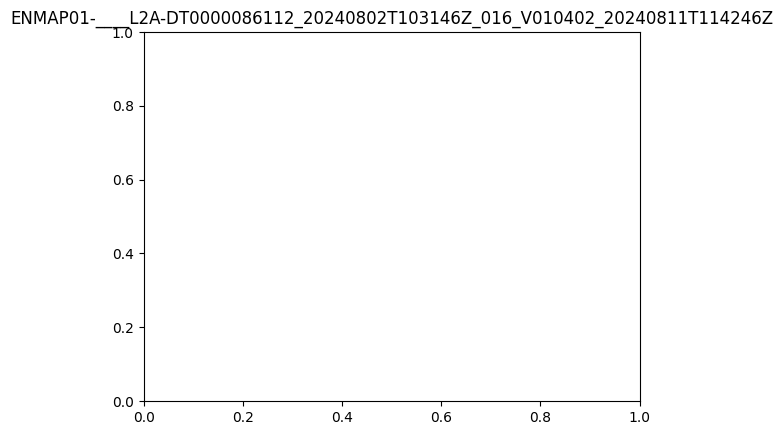

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/08/02/DT0000086112/15/ENMAP01-____L2A-DT0000086112_20240802T103142Z_015_V010402_20240811T113703Z-SPECTRAL_IMAGE_COG.TIF


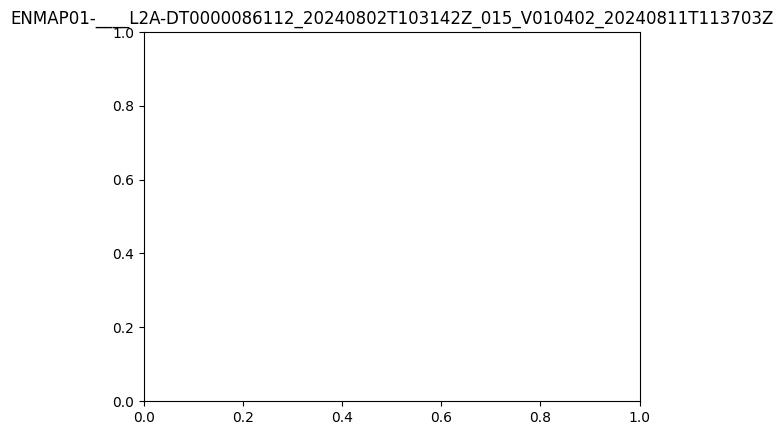

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/06/28/DT0000079993/01/ENMAP01-____L2A-DT0000079993_20240628T102510Z_001_V010402_20240702T034814Z-SPECTRAL_IMAGE_COG.TIF


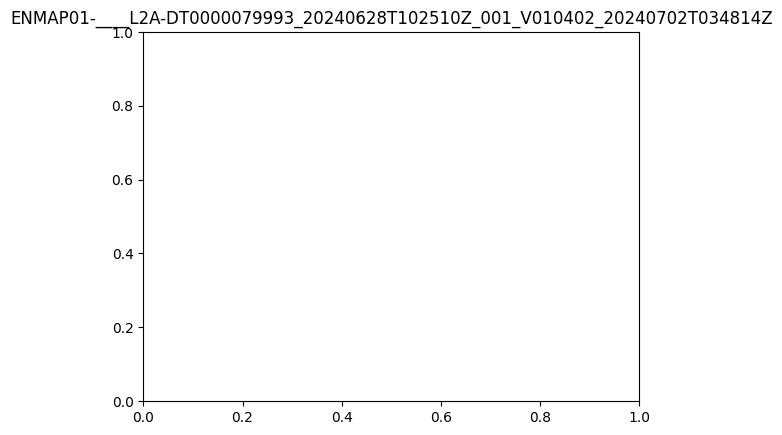

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/06/17/DT0000079769/02/ENMAP01-____L2A-DT0000079769_20240617T103927Z_002_V010402_20240619T100344Z-SPECTRAL_IMAGE_COG.TIF


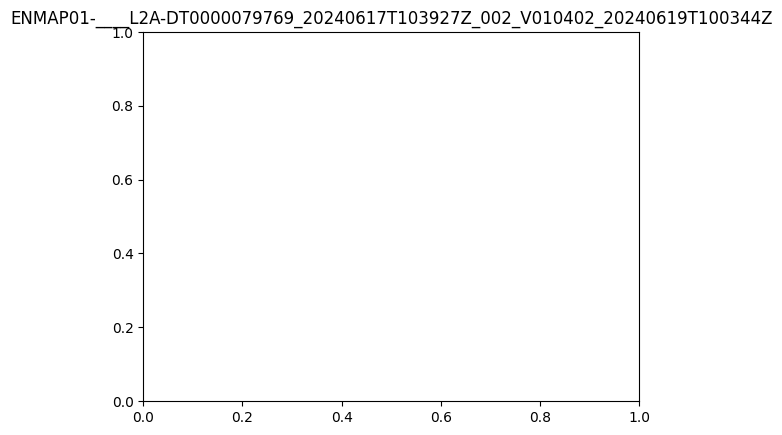

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/06/17/DT0000079769/01/ENMAP01-____L2A-DT0000079769_20240617T103923Z_001_V010402_20240619T100339Z-SPECTRAL_IMAGE_COG.TIF


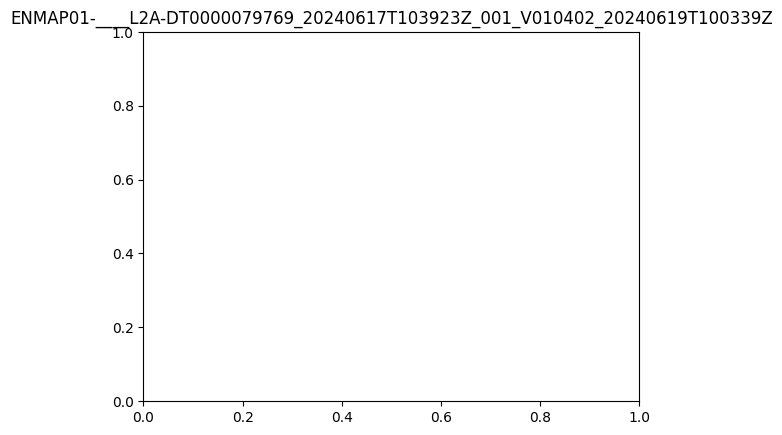

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/06/05/DT0000078174/01/ENMAP01-____L2A-DT0000078174_20240605T102819Z_001_V010402_20240610T230131Z-SPECTRAL_IMAGE_COG.TIF


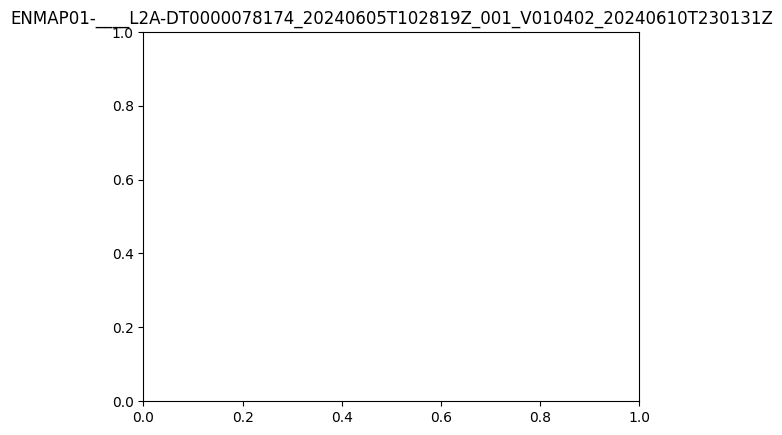

https://download.geoservice.dlr.de/ENMAP/files/L2A/2022/11/04/DT0000004930/15/ENMAP01-____L2A-DT0000004930_20221104T101713Z_015_V010502_20251110T121020Z-SPECTRAL_IMAGE_COG.TIF


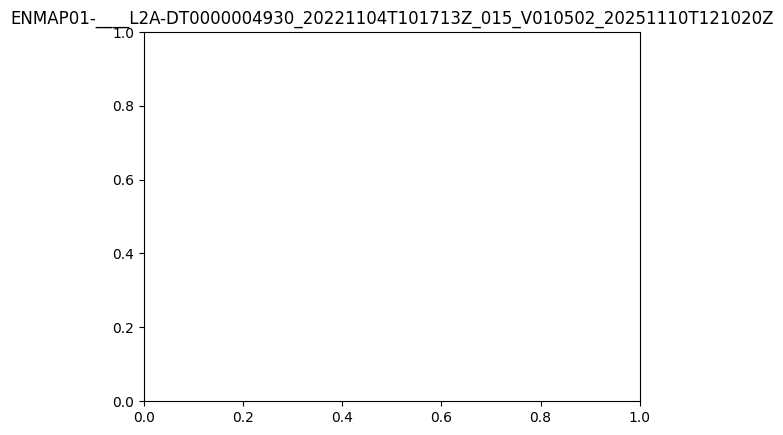

In [26]:
import imageio.v3 as iio
for item in items:
    web_image = item.assets['image'].href
    print(web_image)
    #img = iio.imread(web_image)
    #plt.imshow(img)
    plt.title(item.id)
    plt.show()

In [27]:
df = gpd.GeoDataFrame.from_features(items.to_dict(), crs="epsg:4326")
df.head()

,geometry,version,created,updated,datetime,start_datetime,end_datetime,platform,sat:relative_orbit,sat:orbit_state,...,enmap:swirNumberChannelsMissing,enmap:tileID,enmap:vnirNumberChannelsMissing,enmap:water_cover,eo:instrument,sci:citation,proj:code,proj:epsg,data_type,raster:nodata
0,"POLYGON ((16.3004 48.94019, 16.19173 48.668, 1...",01.05.02,2025-09-17T10:27:50.564+00:00,2025-09-17T10:27:50.564+00:00,2025-09-11T10:32:12Z,2025-09-11T10:32:12.757720Z,2025-09-11T10:32:17.292419Z,enmap,18555,DESCENDING,...,0,16,0,1,HSI,DLR (2025): EnMAP L0 Product 0000152162_16_L0_...,EPSG:32633,NaN,NaN,NaN
1,"POLYGON ((16.40789 49.20743, 16.29842 48.93524...",01.05.02,2025-09-17T10:27:50.337+00:00,2025-09-17T10:27:50.337+00:00,2025-09-11T10:32:08Z,2025-09-11T10:32:08.305603Z,2025-09-11T10:32:12.840329Z,enmap,18555,DESCENDING,...,0,15,0,2,HSI,DLR (2025): EnMAP L0 Product 0000152162_15_L0_...,EPSG:32633,NaN,NaN,NaN
2,"POLYGON ((16.3163 48.96884, 16.20782 48.69657,...",01.05.02,2025-08-22T02:40:52.369+00:00,2025-08-22T02:40:52.369+00:00,2025-08-15T10:31:58Z,2025-08-15T10:31:58.649383Z,2025-08-15T10:32:03.184076Z,enmap,18157,DESCENDING,...,0,16,0,3,HSI,DLR (2025): EnMAP L0 Product 0000147513_16_L0_...,NaN,NaN,NaN,NaN
3,"POLYGON ((16.42349 49.23622, 16.31432 48.96388...",01.05.02,2025-08-22T02:40:52.007+00:00,2025-08-22T02:40:52.007+00:00,2025-08-15T10:31:54Z,2025-08-15T10:31:54.197277Z,2025-08-15T10:31:58.731991Z,enmap,18157,DESCENDING,...,0,15,0,1,HSI,DLR (2025): EnMAP L0 Product 0000147513_15_L0_...,NaN,NaN,NaN,NaN
4,"POLYGON ((16.319 48.9764, 16.21055 48.70396, 1...",01.05.01,2024-11-05T05:59:31.979+00:00,2024-11-05T05:59:31.979+00:00,2024-10-22T10:32:05Z,2024-10-22T10:32:05.789840Z,2024-10-22T10:32:10.324528Z,enmap,13779,DESCENDING,...,0,16,0,0,HSI,DLR (2024): EnMAP L0 Product 0000098426_16_L0_...,NaN,NaN,NaN,NaN


In [28]:
for item in items:
    print(f'Cloud cover for item {item.id}: {item.properties["eo:cloud_cover"]:.2f}')

ValueError: Unknown format code 'f' for object of type 'str'

In [29]:
for item in items:
    cloud_value = item.properties.get("eo:cloud_cover")

    try:
        cloud = float(cloud_value)
        print(f'Cloud cover for item {item.id}: {cloud:.2f}')
    except (TypeError, ValueError):
        print(f'Cloud cover for item {item.id}: not available ({cloud_value})')

Cloud cover for item ENMAP01-____L2A-DT0000152162_20250911T103212Z_016_V010502_20250917T030051Z: 33.00
Cloud cover for item ENMAP01-____L2A-DT0000152162_20250911T103208Z_015_V010502_20250917T030051Z: 6.00
Cloud cover for item ENMAP01-____L2A-DT0000147513_20250815T103158Z_016_V010502_20250821T190844Z: 0.00
Cloud cover for item ENMAP01-____L2A-DT0000147513_20250815T103154Z_015_V010502_20250821T190728Z: 1.00
Cloud cover for item ENMAP01-____L2A-DT0000098426_20241022T103205Z_016_V010501_20241102T021729Z: 100.00
Cloud cover for item ENMAP01-____L2A-DT0000098426_20241022T103201Z_015_V010501_20241102T021730Z: 100.00
Cloud cover for item ENMAP01-____L2A-DT0000094378_20240925T103138Z_016_V010402_20241005T214910Z: 0.00
Cloud cover for item ENMAP01-____L2A-DT0000094378_20240925T103134Z_015_V010402_20241005T214553Z: 3.00
Cloud cover for item ENMAP01-____L2A-DT0000089986_20240829T103215Z_016_V010402_20240902T154145Z: 0.00
Cloud cover for item ENMAP01-____L2A-DT0000089986_20240829T103211Z_015_V01040

In [30]:
filtered_items = []

for item in items:
    cloud = float(item.properties.get("eo:cloud_cover", 100))

    if cloud < 20:
        filtered_items.append(item)
        print(f'{item.id} — cloud cover: {cloud:.2f}%')

print(f"\nSelected {len(filtered_items)} items out of {len(items)}")

ENMAP01-____L2A-DT0000152162_20250911T103208Z_015_V010502_20250917T030051Z — cloud cover: 6.00%
ENMAP01-____L2A-DT0000147513_20250815T103158Z_016_V010502_20250821T190844Z — cloud cover: 0.00%
ENMAP01-____L2A-DT0000147513_20250815T103154Z_015_V010502_20250821T190728Z — cloud cover: 1.00%
ENMAP01-____L2A-DT0000094378_20240925T103138Z_016_V010402_20241005T214910Z — cloud cover: 0.00%
ENMAP01-____L2A-DT0000094378_20240925T103134Z_015_V010402_20241005T214553Z — cloud cover: 3.00%
ENMAP01-____L2A-DT0000089986_20240829T103215Z_016_V010402_20240902T154145Z — cloud cover: 0.00%
ENMAP01-____L2A-DT0000089986_20240829T103211Z_015_V010402_20240902T154033Z — cloud cover: 0.00%
ENMAP01-____L2A-DT0000079769_20240617T103927Z_002_V010402_20240619T100344Z — cloud cover: 0.00%
ENMAP01-____L2A-DT0000079769_20240617T103923Z_001_V010402_20240619T100339Z — cloud cover: 0.00%
ENMAP01-____L2A-DT0000078174_20240605T102819Z_001_V010402_20240610T230131Z — cloud cover: 7.00%

Selected 10 items out of 17


In [31]:
for item in filtered_items:
    print(item.id, list(item.assets.keys()))

ENMAP01-____L2A-DT0000152162_20250911T103208Z_015_V010502_20250917T030051Z ['metadata', 'image', 'vnir', 'thumbnail', 'swir', 'quality_classes', 'quality_cloud', 'quality_cloud_shadow', 'quality_haze', 'quality_cirrus', 'quality_snow', 'quality_testflags', 'defective_pixel_mask']
ENMAP01-____L2A-DT0000147513_20250815T103158Z_016_V010502_20250821T190844Z ['metadata', 'image', 'vnir', 'thumbnail', 'swir', 'quality_classes', 'quality_cloud', 'quality_cloud_shadow', 'quality_haze', 'quality_cirrus', 'quality_snow', 'quality_testflags', 'defective_pixel_mask']
ENMAP01-____L2A-DT0000147513_20250815T103154Z_015_V010502_20250821T190728Z ['metadata', 'image', 'vnir', 'thumbnail', 'swir', 'quality_classes', 'quality_cloud', 'quality_cloud_shadow', 'quality_haze', 'quality_cirrus', 'quality_snow', 'quality_testflags', 'defective_pixel_mask']
ENMAP01-____L2A-DT0000094378_20240925T103138Z_016_V010402_20241005T214910Z ['metadata', 'image', 'vnir', 'thumbnail', 'swir', 'quality_classes', 'quality_clo

https://download.geoservice.dlr.de/ENMAP/files/L2A/2025/09/11/DT0000152162/15/ENMAP01-____L2A-DT0000152162_20250911T103208Z_015_V010502_20250917T030051Z-SPECTRAL_IMAGE_COG.TIF


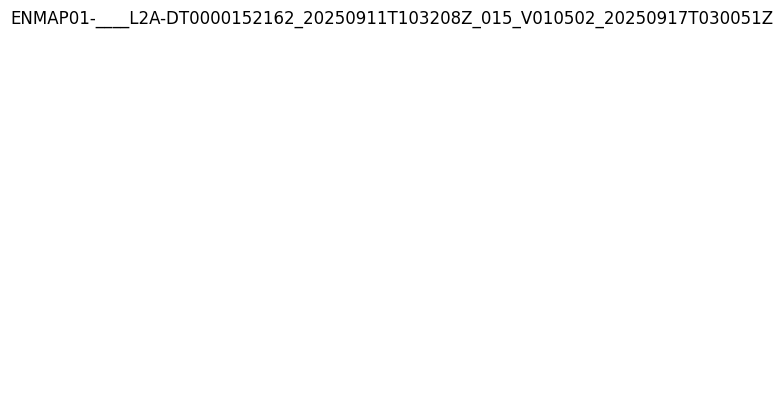

https://download.geoservice.dlr.de/ENMAP/files/L2A/2025/08/15/DT0000147513/16/ENMAP01-____L2A-DT0000147513_20250815T103158Z_016_V010502_20250821T190844Z-SPECTRAL_IMAGE_COG.TIF


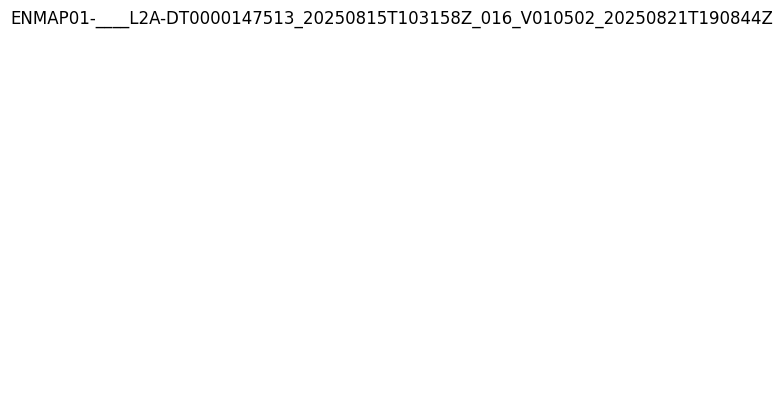

https://download.geoservice.dlr.de/ENMAP/files/L2A/2025/08/15/DT0000147513/15/ENMAP01-____L2A-DT0000147513_20250815T103154Z_015_V010502_20250821T190728Z-SPECTRAL_IMAGE_COG.TIF


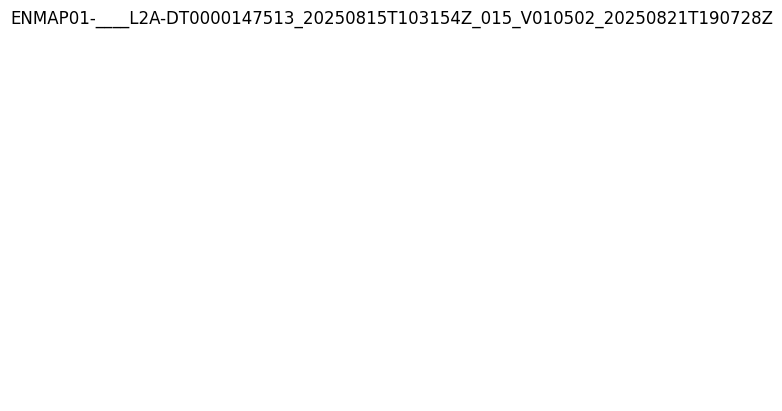

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/09/25/DT0000094378/16/ENMAP01-____L2A-DT0000094378_20240925T103138Z_016_V010402_20241005T214910Z-SPECTRAL_IMAGE_COG.TIF


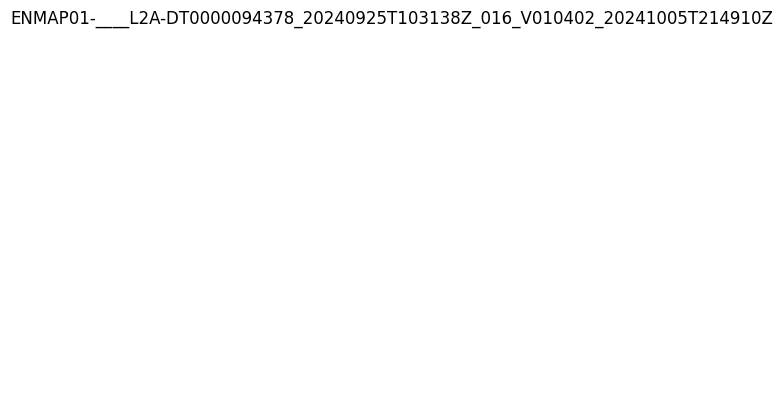

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/09/25/DT0000094378/15/ENMAP01-____L2A-DT0000094378_20240925T103134Z_015_V010402_20241005T214553Z-SPECTRAL_IMAGE_COG.TIF


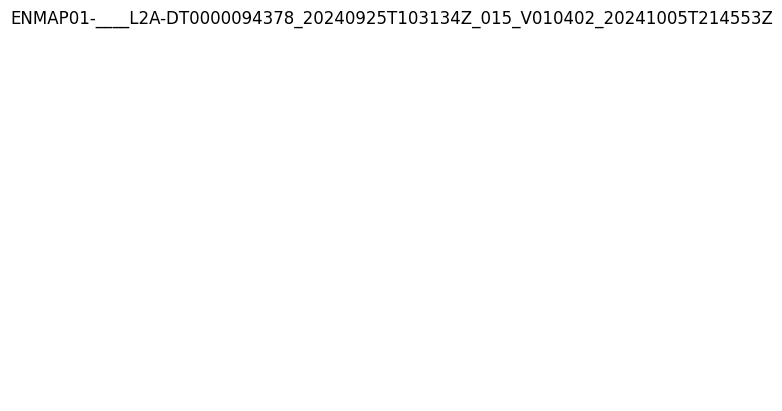

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/08/29/DT0000089986/16/ENMAP01-____L2A-DT0000089986_20240829T103215Z_016_V010402_20240902T154145Z-SPECTRAL_IMAGE_COG.TIF


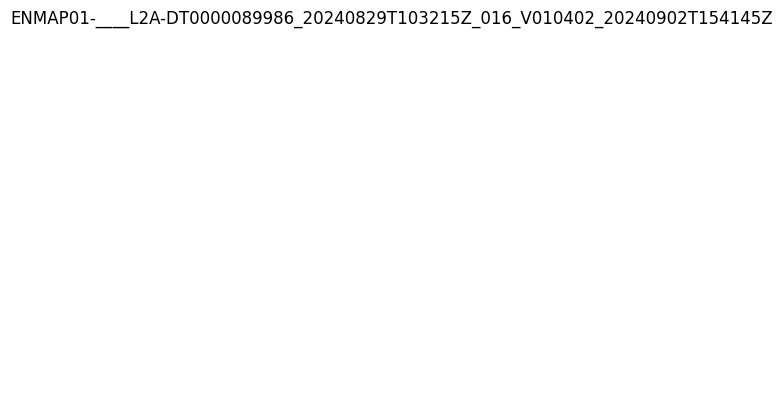

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/08/29/DT0000089986/15/ENMAP01-____L2A-DT0000089986_20240829T103211Z_015_V010402_20240902T154033Z-SPECTRAL_IMAGE_COG.TIF


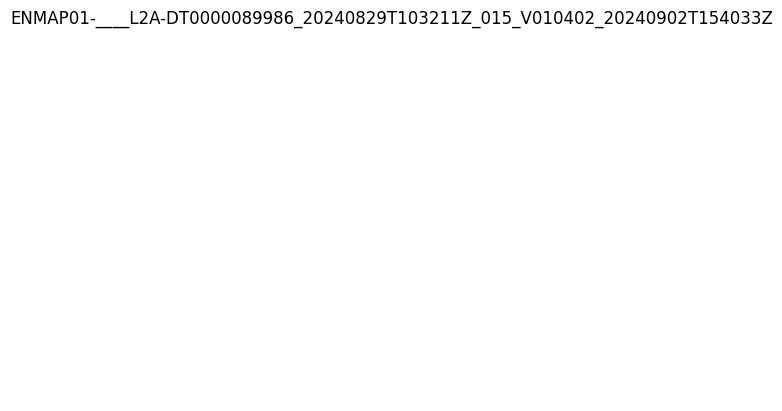

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/06/17/DT0000079769/02/ENMAP01-____L2A-DT0000079769_20240617T103927Z_002_V010402_20240619T100344Z-SPECTRAL_IMAGE_COG.TIF


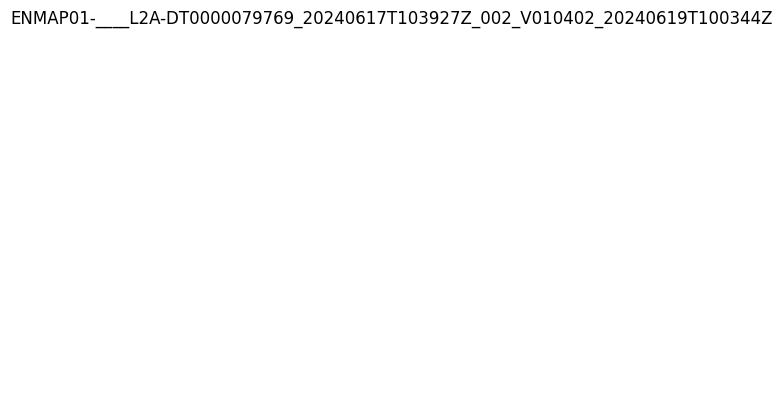

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/06/17/DT0000079769/01/ENMAP01-____L2A-DT0000079769_20240617T103923Z_001_V010402_20240619T100339Z-SPECTRAL_IMAGE_COG.TIF


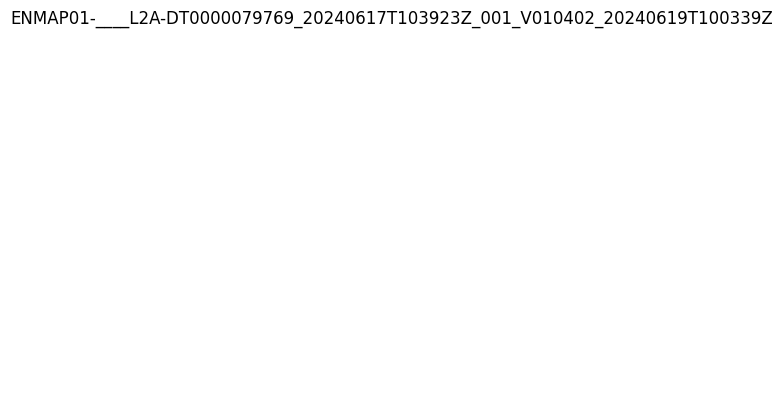

https://download.geoservice.dlr.de/ENMAP/files/L2A/2024/06/05/DT0000078174/01/ENMAP01-____L2A-DT0000078174_20240605T102819Z_001_V010402_20240610T230131Z-SPECTRAL_IMAGE_COG.TIF


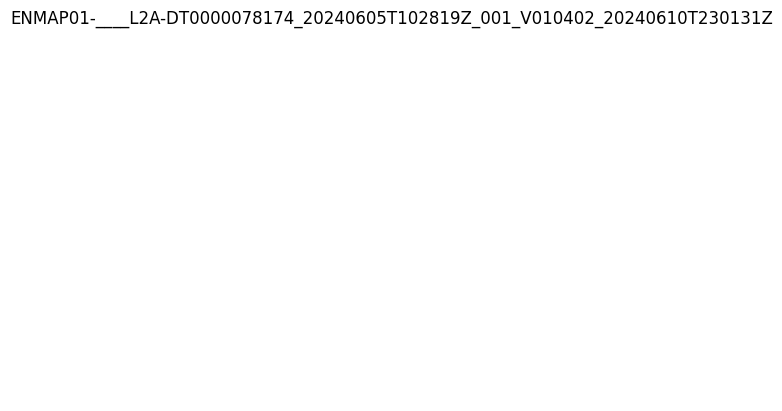

In [ ]:
import imageio.v3 as iio
import matplotlib.pyplot as plt

for item in filtered_items:   # ← změna z items na filtered_items
    web_image = item.assets['image'].href
    
    print(web_image)

    #img = iio.imread(web_image)  
    #plt.imshow(img)
    plt.title(item.id)
    plt.axis("off")
    plt.show()

Raster bounds: BoundingBox(left=588855.0, bottom=5388645.0, right=625725.0, top=5424855.0)
Polygon bounds: [ 609366.65907927 5412389.09931581  616922.13177592 5418025.80262465]
Dtype rastru: int16
NoData: -32768.0
Shape po klipu: (224, 189, 253)
Green band index: 21
NIR band index: 70


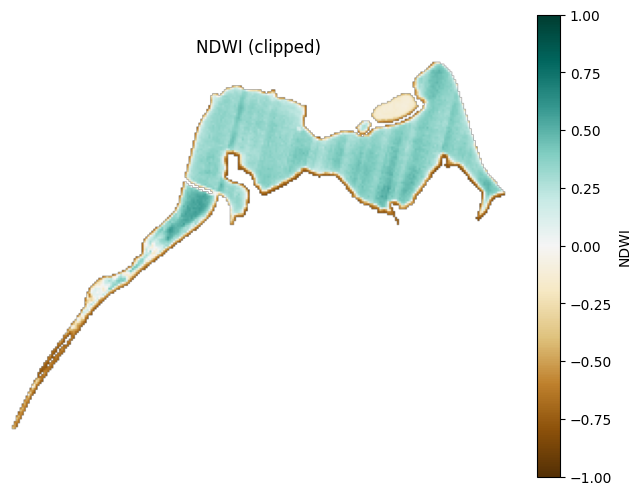

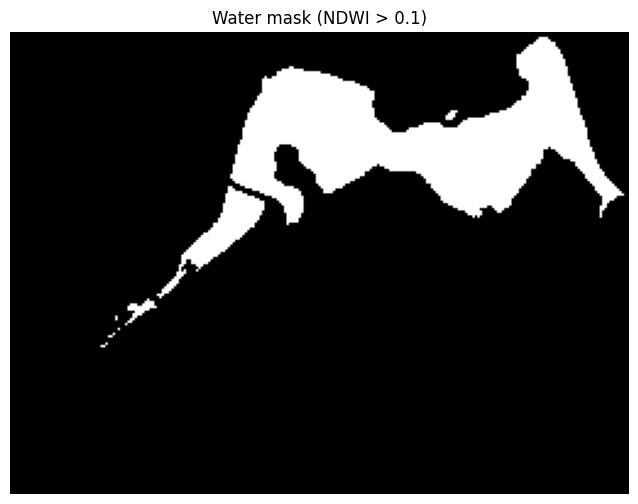

In [13]:
from pathlib import Path
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

# vstupní raster
out_file = Path(
    r"C:\Users\Dell\Downloads\ENMAP01-____L2A-DT0000147513_20250815T103158Z_016_V010502_20250821T190844Z-SPECTRAL_IMAGE_COG.tiff"
)

# polygon
poly_file = Path(
    r"C:\Users\Dell\Documents\diplomka\data_AOI\AOI.geojson"
)

# načti polygon
gdf = gpd.read_file(poly_file)
gdf = gdf[gdf.geometry.notnull()].copy()
gdf["geometry"] = gdf.buffer(0)

with rasterio.open(out_file) as src:
    if gdf.crs != src.crs:
        gdf = gdf.to_crs(src.crs)

    print("Raster bounds:", src.bounds)
    print("Polygon bounds:", gdf.total_bounds)
    print("Dtype rastru:", src.dtypes[0])
    print("NoData:", src.nodata)

    # klip bez NaN při maskování
    cube, transform = mask(
        src,
        gdf.geometry.tolist(),
        crop=True,
        filled=True,
        nodata=src.nodata
    )

    nodata = src.nodata

# až teď převod na float
cube = cube.astype("float32")

# nodata -> NaN
if nodata is not None:
    cube[cube == nodata] = np.nan

print("Shape po klipu:", cube.shape)

# --------------------------------------------------
# Přibližný výběr VNIR pásem pro NDWI
# --------------------------------------------------
vnir_min = 418.2
vnir_max = 993.0
vnir_bands = 91

vnir_wavelengths = np.linspace(vnir_min, vnir_max, vnir_bands)

target_green = 553.0
target_nir = 865.0

green_idx = int(np.argmin(np.abs(vnir_wavelengths - target_green)))
nir_idx = int(np.argmin(np.abs(vnir_wavelengths - target_nir)))

print("Green band index:", green_idx)
print("NIR band index:", nir_idx)

green = cube[green_idx]
nir = cube[nir_idx]

# NDWI
ndwi = (green - nir) / (green + nir + 1e-10)
ndwi = np.clip(ndwi, -1, 1)

plt.figure(figsize=(8, 6))
plt.imshow(ndwi, vmin=-1, vmax=1, cmap="BrBG")
plt.colorbar(label="NDWI")
plt.title("NDWI (clipped)")
plt.axis("off")
plt.show()

water_mask = ndwi > 0.1

plt.figure(figsize=(8, 6))
plt.imshow(water_mask, cmap="gray")
plt.title("Water mask (NDWI > 0.1)")
plt.axis("off")
plt.show()

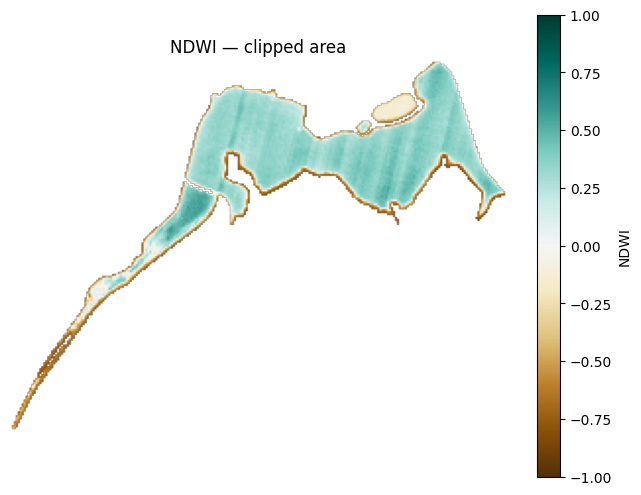

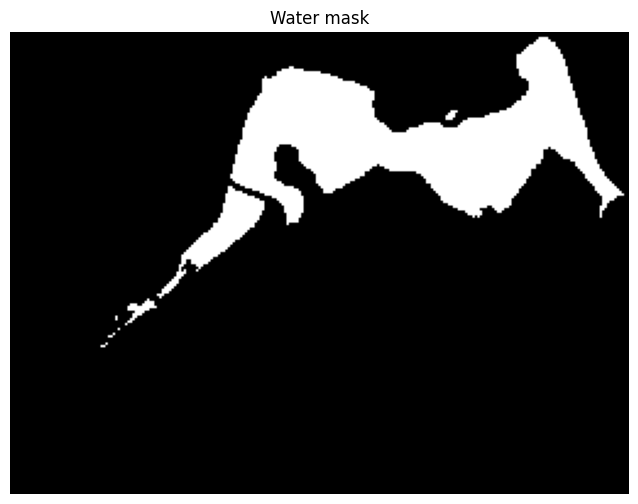

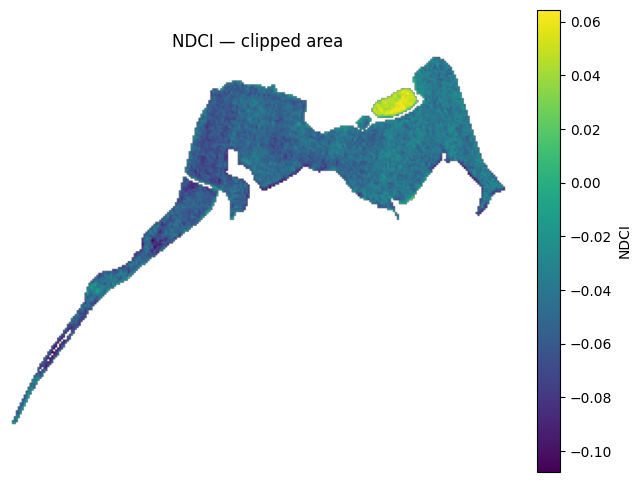

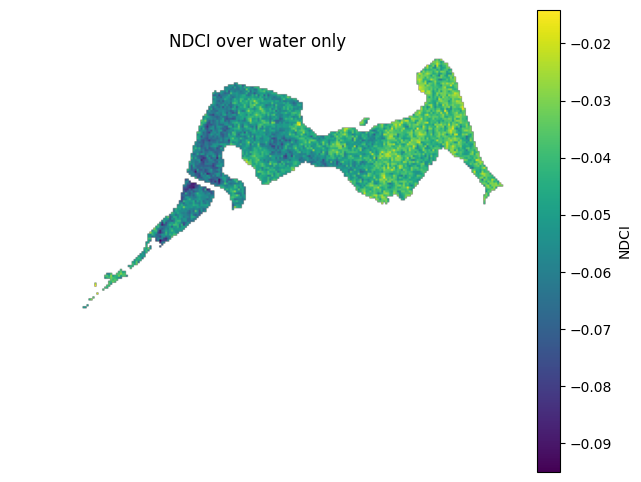

NDCI uložen do: C:\Users\Dell\Downloads\ndci_clipped.tif


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# VNIR pásma
# --------------------------------------------------
vnir_min = 418.2
vnir_max = 993.0
vnir_bands = 91
vnir_wavelengths = np.linspace(vnir_min, vnir_max, vnir_bands)

# --------------------------------------------------
# NDWI
# --------------------------------------------------
target_green = 553.0
target_nir = 865.0

green_idx = int(np.argmin(np.abs(vnir_wavelengths - target_green)))
nir_idx = int(np.argmin(np.abs(vnir_wavelengths - target_nir)))

green = cube[green_idx].astype("float32")
nir = cube[nir_idx].astype("float32")

ndwi = (green - nir) / (green + nir + 1e-10)
ndwi = np.clip(ndwi, -1, 1)

water_mask = ndwi > 0.1

plt.figure(figsize=(8, 6))
plt.imshow(ndwi, vmin=-1, vmax=1, cmap="BrBG")
plt.colorbar(label="NDWI")
plt.title("NDWI — clipped area")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(water_mask, cmap="gray")
plt.title("Water mask")
plt.axis("off")
plt.show()

# --------------------------------------------------
# NDCI
# --------------------------------------------------
target_red = 665.0
target_rededge = 708.0

red_idx = int(np.argmin(np.abs(vnir_wavelengths - target_red)))
rededge_idx = int(np.argmin(np.abs(vnir_wavelengths - target_rededge)))

red = cube[red_idx].astype("float32")
rededge = cube[rededge_idx].astype("float32")

ndci = (rededge - red) / (rededge + red + 1e-10)
ndci = np.clip(ndci, -1, 1)

# jen voda
ndci_water = np.where(water_mask, ndci, np.nan)

plt.figure(figsize=(8, 6))
plt.imshow(ndci, cmap="viridis")
plt.colorbar(label="NDCI")
plt.title("NDCI — clipped area")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(ndci_water, cmap="viridis")
plt.colorbar(label="NDCI")
plt.title("NDCI over water only")
plt.axis("off")
plt.show()

from pathlib import Path
import rasterio
import numpy as np

# cesta výstupu
ndci_file = Path(
    r"C:\Users\Dell\Downloads\ndci_clipped.tif"
)

# metadata pro výstup
profile = {
    "driver": "GTiff",
    "height": ndci.shape[0],
    "width": ndci.shape[1],
    "count": 1,
    "dtype": "float32",
    "crs": src.crs,
    "transform": transform,
    "nodata": np.nan
}

# uložení
with rasterio.open(ndci_file, "w", **profile) as dst:
    dst.write(ndci.astype("float32"), 1)

print("NDCI uložen do:", ndci_file)

In [16]:
print("cube min/max:", np.nanmin(cube), np.nanmax(cube))
print("red idx, wl:", red_idx, vnir_wavelengths[red_idx])
print("rededge idx, wl:", rededge_idx, vnir_wavelengths[rededge_idx])
print("ndci min/max:", np.nanmin(ndci), np.nanmax(ndci))

cube min/max: -401.0 4813.0
red idx, wl: 39 667.28
rededge idx, wl: 45 705.5999999999999
ndci min/max: -0.10778443 0.06439394


In [22]:
import numpy as np

vnir_min = 418.2
vnir_max = 993.0
vnir_bands = 91
vnir_wavelengths = np.linspace(vnir_min, vnir_max, vnir_bands)

red_candidates = np.arange(660, 681, 5)       # 660, 665, 670, 675, 680
rededge_candidates = np.arange(700, 731, 5)   # 700, 705, 710, ..., 730

results = []

for target_red in red_candidates:
    for target_rededge in rededge_candidates:
        if target_rededge <= target_red:
            continue

        red_idx = int(np.argmin(np.abs(vnir_wavelengths - target_red)))
        rededge_idx = int(np.argmin(np.abs(vnir_wavelengths - target_rededge)))

        red = cube[red_idx].astype("float32")
        rededge = cube[rededge_idx].astype("float32")

        ndci = (rededge - red) / (rededge + red + 1e-10)
        ndci = np.clip(ndci, -1, 1)

        vals = ndci[~np.isnan(ndci)]

        results.append((
            target_red,
            target_rededge,
            red_idx,
            rededge_idx,
            vnir_wavelengths[red_idx],
            vnir_wavelengths[rededge_idx],
            float(np.nanmin(vals)),
            float(np.nanmax(vals)),
            float(np.nanmean(vals)),
            float(np.nanmedian(vals)),
        ))

# seřadit podle maxima
results_sorted = sorted(results, key=lambda x: x[7], reverse=True)

print("TOP kombinace podle maxima NDCI:")
for r in results_sorted[:10]:
    print(
        f"target_red={r[0]} nm, target_rededge={r[1]} nm | "
        f"used_red={r[4]:.2f} nm, used_rededge={r[5]:.2f} nm | "
        f"min={r[6]:.4f}, max={r[7]:.4f}, mean={r[8]:.4f}, median={r[9]:.4f}"
    )

TOP kombinace podle maxima NDCI:
target_red=680 nm, target_rededge=705 nm | used_red=680.05 nm, used_rededge=705.60 nm | min=-0.0982, max=0.0993, mean=-0.0303, median=-0.0310
target_red=680 nm, target_rededge=700 nm | used_red=680.05 nm, used_rededge=699.21 nm | min=-0.0612, max=0.0958, mean=-0.0003, median=0.0000
target_red=675 nm, target_rededge=705 nm | used_red=673.67 nm, used_rededge=705.60 nm | min=-0.1064, max=0.0865, mean=-0.0410, median=-0.0419
target_red=675 nm, target_rededge=700 nm | used_red=673.67 nm, used_rededge=699.21 nm | min=-0.0933, max=0.0795, mean=-0.0110, median=-0.0103
target_red=665 nm, target_rededge=705 nm | used_red=667.28 nm, used_rededge=705.60 nm | min=-0.1078, max=0.0644, mean=-0.0456, median=-0.0471
target_red=670 nm, target_rededge=705 nm | used_red=667.28 nm, used_rededge=705.60 nm | min=-0.1078, max=0.0644, mean=-0.0456, median=-0.0471
target_red=665 nm, target_rededge=700 nm | used_red=667.28 nm, used_rededge=699.21 nm | min=-0.0772, max=0.0582, mea

Green band: 22 558.7066666666667
Red band: 39 667.28
EnMAP NDTI polygon only:
min: -0.080568716
max: 0.125
mean: 0.02125649
median: 0.023752974


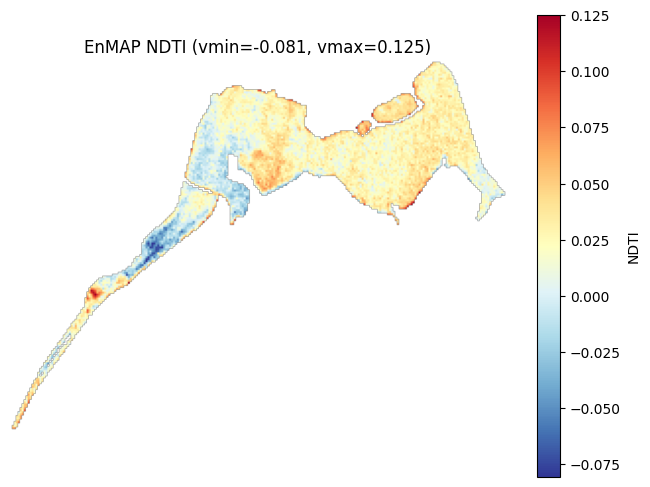

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# VNIR rozsah EnMAP
vnir_min = 418.2
vnir_max = 993.0
vnir_bands = 91

vnir_wavelengths = np.linspace(vnir_min, vnir_max, vnir_bands)

# cílové vlnové délky
target_green = 560.0   # můžeš zkusit i 553.0
target_red = 665.0

green_idx = int(np.argmin(np.abs(vnir_wavelengths - target_green)))
red_idx = int(np.argmin(np.abs(vnir_wavelengths - target_red)))

print("Green band:", green_idx, vnir_wavelengths[green_idx])
print("Red band:", red_idx, vnir_wavelengths[red_idx])

green = cube[green_idx].astype("float32")
red = cube[red_idx].astype("float32")

# NDTI
ndti = (red - green) / (red + green + 1e-10)
ndti = np.clip(ndti, -1, 1)

# statistiky
vals = ndti[~np.isnan(ndti)]
print("EnMAP NDTI polygon only:")
print("min:", np.nanmin(vals))
print("max:", np.nanmax(vals))
print("mean:", np.nanmean(vals))
print("median:", np.nanmedian(vals))

vmin = np.nanmin(vals)
vmax = np.nanmax(vals)

# mapa
plt.figure(figsize=(8, 6))
plt.imshow(ndti, cmap="RdYlBu_r", vmin=vmin, vmax=vmax)
plt.colorbar(label="NDTI")
plt.title(f"EnMAP NDTI (vmin={vmin:.3f}, vmax={vmax:.3f})")
plt.axis("off")
plt.show()

Shape: (224, 1207, 1229)
Green band index (0-based in full cube): 21
Green wavelength approx: 552.3199999999999
NIR band index (0-based in full cube): 70
NIR wavelength approx: 865.2666666666667


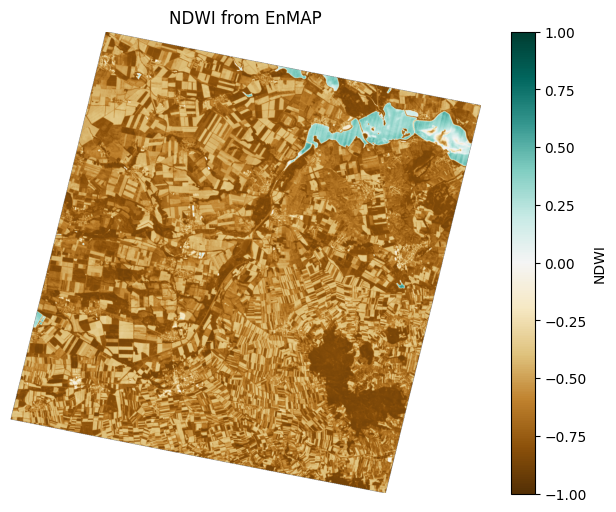

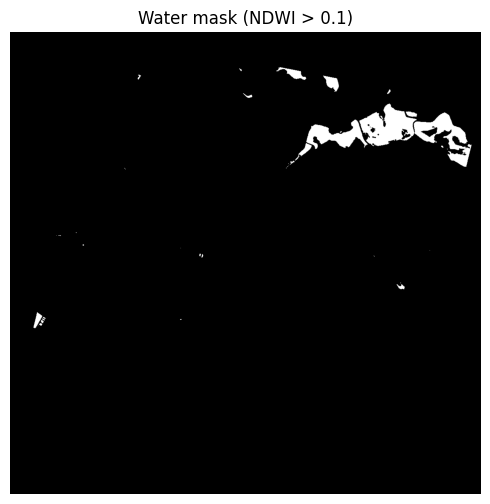

In [7]:
from pathlib import Path
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# cesta k EnMAP TIFF
out_file = Path(
    r"C:\Users\Dell\Downloads\ENMAP01-____L2A-DT0000147513_20250815T103158Z_016_V010502_20250821T190844Z-SPECTRAL_IMAGE_COG.tiff"
)

# načtení kostky
with rasterio.open(out_file) as src:
    cube = src.read().astype("float32")
    nodata = src.nodata

# nodata -> NaN
if nodata is not None:
    cube[cube == nodata] = np.nan

print("Shape:", cube.shape)

# --------------------------------------------------
# Přibližný výběr EnMAP VNIR pásem pro NDWI
# VNIR ~ 418.2 až 993.0 nm
# Green cíl ~ 553 nm
# NIR cíl ~ 865 nm
# --------------------------------------------------

vnir_min = 418.2
vnir_max = 993.0
vnir_bands = 91   # nominální VNIR počet pásem

# přibližné střední vlnové délky VNIR pásem
vnir_wavelengths = np.linspace(vnir_min, vnir_max, vnir_bands)

target_green = 553.0
target_nir = 865.0

green_idx = int(np.argmin(np.abs(vnir_wavelengths - target_green)))   # 0-based v rámci VNIR
nir_idx = int(np.argmin(np.abs(vnir_wavelengths - target_nir)))       # 0-based v rámci VNIR

print("Green band index (0-based in full cube):", green_idx)
print("Green wavelength approx:", vnir_wavelengths[green_idx])

print("NIR band index (0-based in full cube):", nir_idx)
print("NIR wavelength approx:", vnir_wavelengths[nir_idx])

green = cube[green_idx]
nir = cube[nir_idx]

# NDWI
ndwi = (green - nir) / (green + nir + 1e-10)

# jednoduché omezení extrémů
ndwi = np.clip(ndwi, -1, 1)

# zobrazení NDWI
plt.figure(figsize=(8, 6))
plt.imshow(ndwi, vmin=-1, vmax=1, cmap="BrBG")
plt.colorbar(label="NDWI")
plt.title("NDWI from EnMAP")
plt.axis("off")
plt.show()

# volitelně: maska vody
water_mask = ndwi > 0.1

plt.figure(figsize=(8, 6))
plt.imshow(water_mask, cmap="gray")
plt.title("Water mask (NDWI > 0.1)")
plt.axis("off")
plt.show()

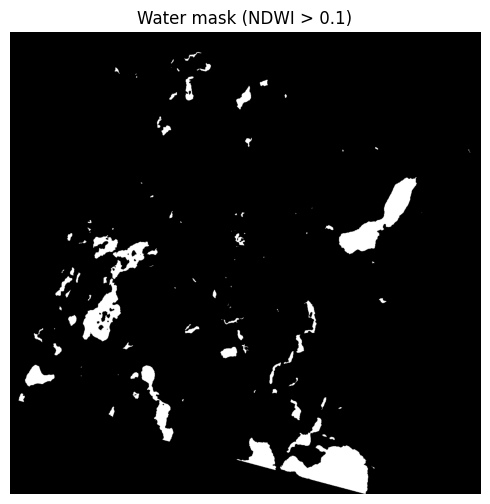

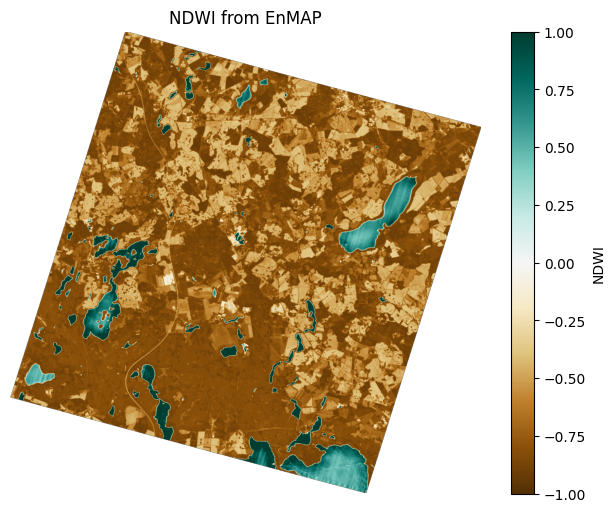

In [90]:
import matplotlib.pyplot as plt
import numpy as np

green = cube[21].astype("float32")
nir = cube[70].astype("float32")

ndwi = (green - nir) / (green + nir + 1e-10)
ndwi = np.clip(ndwi, -1, 1)

water_mask = ndwi > 0.1

plt.figure(figsize=(8, 6))
plt.imshow(water_mask, cmap="gray")
plt.title("Water mask (NDWI > 0.1)")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(ndwi, vmin=-1, vmax=1, cmap="BrBG")
plt.colorbar(label="NDWI")
plt.title("NDWI from EnMAP")
plt.axis("off")
plt.show()

Red band: 39 667.28
Red-edge band: 45 705.5999999999999


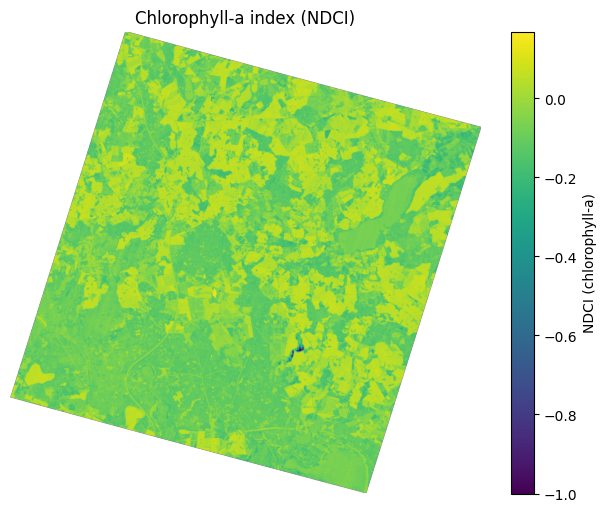

In [91]:
import numpy as np
import matplotlib.pyplot as plt

# VNIR rozsah EnMAP
vnir_min = 418.2
vnir_max = 993.0
vnir_bands = 91

vnir_wavelengths = np.linspace(vnir_min, vnir_max, vnir_bands)

target_red = 665
target_rededge = 708

red_idx = int(np.argmin(np.abs(vnir_wavelengths - target_red)))
rededge_idx = int(np.argmin(np.abs(vnir_wavelengths - target_rededge)))

print("Red band:", red_idx, vnir_wavelengths[red_idx])
print("Red-edge band:", rededge_idx, vnir_wavelengths[rededge_idx])

red = cube[red_idx].astype("float32")
rededge = cube[rededge_idx].astype("float32")

ndci = (rededge - red) / (rededge + red + 1e-10)

ndci = np.clip(ndci, -1, 1)

plt.figure(figsize=(8, 6))
plt.imshow(ndci, cmap="viridis")
plt.colorbar(label="NDCI (chlorophyll-a)")
plt.title("Chlorophyll-a index (NDCI)")
plt.axis("off")
plt.show()

In [38]:
ndci_water = np.where(water_mask, ndci, np.nan)
plt.figure(figsize=(8,6))

plt.imshow(
    ndci_water,
    cmap="viridis",
    vmin=0,
    vmax=0.4
)

plt.colorbar(label="NDCI (water only)")
plt.title("Chlorophyll-a (water masked)")
plt.axis("off")

plt.show()

ValueError: operands could not be broadcast together with shapes (1178,1205) (1247,1295) () 

In [18]:
import rasterio

output_file = Path(
    r"C:\Users\Dell\Downloads\ndci_water.tif"
)

with rasterio.open(out_file) as src:
    profile = src.profile.copy()

profile.update(
    dtype="float32",
    count=1,
    nodata=-9999
)

ndci_out = np.where(
    np.isnan(ndci_water),
    -9999,
    ndci_water
).astype("float32")

with rasterio.open(output_file, "w", **profile) as dst:
    dst.write(ndci_out, 1)

print("Saved:", output_file)

Saved: C:\Users\Dell\Downloads\ndci_water.tif


In [85]:
valid_items = []

aoi_geom = area_of_interest.geometry.iloc[0]

for item in items:
    scene_geom = shape(item.geometry)

    if scene_geom.contains(aoi_geom):
        valid_items.append(item)
print("Počet snímků pokrývajících celý polygon:")
print(len(valid_items))

AttributeError: 'dict' object has no attribute 'geometry'

In [9]:
from pathlib import Path
import rasterio
import geopandas as gpd

out_file = Path(r"C:\Users\Dell\Downloads\ENMAP01-____L2A-DT0000147513_20250815T103154Z_015_V010502_20250821T190728Z-SPECTRAL_IMAGE_COG.tiff")
poly_file = Path(r"C:\Users\Dell\Documents\diplomka\data_AOI\AOI.geojson")

gdf = gpd.read_file(poly_file)

with rasterio.open(out_file) as src:
    print("=== RASTER ===")
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Transform:", src.transform)
    print()

print("=== POLYGON ===")
print("CRS:", gdf.crs)
print("Bounds:", gdf.total_bounds)
print(gdf.head())

=== RASTER ===
CRS: EPSG:32633
Bounds: BoundingBox(left=596175.0, bottom=5418495.0, right=633015.0, top=5454705.0)
Transform: | 30.00, 0.00, 596175.00|
| 0.00,-30.00, 5454705.00|
| 0.00, 0.00, 1.00|

=== POLYGON ===
CRS: EPSG:32633
Bounds: [ 609366.65907927 5412389.09931581  616922.13177592 5418025.80262465]
   OBJECTID             JMENO    SHAPE_Leng DATA50_K      DATA50_P  \
0         1      Velká laguna   1776.702730  3330000  vodní plocha   
1         2       Malá laguna    676.192268  3330000  vodní plocha   
2         1  Nové Mlýny-horní  30322.836137  3330000  vodní plocha   

   Shape_Length    Shape_Area  BUFF_DIST  ORIG_FID  \
0   1776.419411  2.007629e+05        NaN       NaN   
1    676.083194  3.341765e+04        NaN       NaN   
2  30119.095941  6.782241e+06       10.0       1.0   

                         layer  \
0                       laguny   
1                       laguny   
2  Nove_mlyny_horni_buffer_10m   

                                                path  \